In [1]:
from lib.artificial_data import ArtificialTrackDataset, generate_dataset_with_similarities
from lib.user_similarities import calculate_users_track_common_percentage
from lib.plotting import plot_user_similarities_matrix
from lib.matrix_dataset import MatrixDataset
from lib.spoti import NUMERICAL_FEATURES, PRETTY_PRINT_FEATURES
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
SIMPLIFIED_FEATURES = [
    "danceability",
    "duration_ms",
    "instrumentalness",
    "affinity"
]

In [3]:
df_1 = ArtificialTrackDataset(
    default_value=2,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "owen"},
).randomize()

df_2 = ArtificialTrackDataset(
    default_value=3,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "paul"},
).randomize().insert_some_tracks(df_1, 0.5, 0.5)[0].randomize(["affinity"]).shuffle()

df = df_1.merge(df_2)

display(df.data)

,id,username,danceability,duration_ms,instrumentalness,affinity
0,Carry as,owen,0.992913,0.899609,1.092949,0.914496
1,Cold yes,owen,0.919211,0.940014,0.986906,1.024679
2,Moment design,owen,0.951397,0.968814,0.921548,0.998251
3,What top,owen,0.782095,1.046026,1.094335,0.971795
4,Fly common add,owen,0.991096,1.021953,0.889163,1.001706
5,Drive many,paul,1.085188,1.015213,1.182628,1.041248
6,Fly common add,paul,0.991096,1.021953,0.889163,0.999657
7,What top,paul,0.782095,1.046026,1.094335,0.836751
8,Meet loss,paul,0.942735,0.826192,1.054648,1.290917
9,Main sell seem,paul,0.971175,1.014258,0.977785,0.957743


In [4]:
df = generate_dataset_with_similarities(
    num_users=500,
    n_samples=150,
    numerical_features=SIMPLIFIED_FEATURES,
    affinity_feature="affinity",
    max_track_mixing_percentage=0.5,
    min_track_mixing_percentage=0.1,
    mix_with_someone_else_chance=0.4,
)
df.data

Mixing user Stephanie Ross with Tony Hill with a replacement percentage of 18.00%
Mixing user Amanda Bautista with Justin Johnson with a replacement percentage of 34.00%
Mixing user Bryan Morris with Kevin Jackson with a replacement percentage of 42.67%
Mixing user Mark Baker with Heather Sims with a replacement percentage of 34.67%
Mixing user Ann Newman with Ryan Richardson with a replacement percentage of 15.33%
Mixing user Russell Lyons with Tony Anthony with a replacement percentage of 26.00%
Mixing user Mark Simmons with Mark Bailey with a replacement percentage of 12.00%
Mixing user Beverly Mercado with Jacqueline Simpson with a replacement percentage of 11.33%
Mixing user Jeremy Davidson with Amber Martin with a replacement percentage of 48.67%
Mixing user Patrick Vaughn with Christine Brooks with a replacement percentage of 25.33%
Mixing user Samantha Williams with Carla Ramirez with a replacement percentage of 14.67%
Mixing user Jacqueline Garcia with James Evans with a repla

,id,username,danceability,duration_ms,instrumentalness,affinity
0,Like our,Stephanie Ross,1.097810,1.106378,0.827376,1.046303
1,Agreement edge,Stephanie Ross,0.980323,0.986394,0.891645,0.983438
2,Fall now,Stephanie Ross,0.966937,1.072459,0.983861,0.840411
3,Effort force,Stephanie Ross,0.991403,0.946099,0.900673,1.069749
4,She hand along,Stephanie Ross,1.028425,1.239711,0.975480,1.035693
...,...,...,...,...,...,...
74995,Field,Katherine Collins,0.960452,0.872828,1.059360,1.114137
74996,Call since,Katherine Collins,1.051071,0.940491,1.013802,0.997422
74997,Believe,Katherine Collins,0.985555,1.057202,0.961972,0.868880
74998,Light miss,Katherine Collins,1.004798,0.994748,0.929090,0.962596


In [5]:
df_track_common = calculate_users_track_common_percentage(df.data, username_col="username", trackname_col="id")
df_track_common

username,Aaron Coleman,Adam Burke,Adrian Cummings,Alan Garcia,Albert Nelson,Alejandra Mayer,Alex Key,Alexander Sanders,Alicia Patterson,Alison Charles,...,Tyler Suarez,Valerie Carpenter,Valerie Johnson,Vanessa Baldwin,Victoria Flores,Vincent Barnes,Wayne Wiggins,William Gonzales,William Perez,William Smith
username,,,,,,,,,,,,,,,,,,,,,
Aaron Coleman,1.013333,0.013333,0.026667,0.026667,0.026667,0.006667,0.033333,0.033333,0.006667,0.000000,...,0.013333,0.013333,0.013333,0.013333,0.026667,0.020000,0.033333,0.026667,0.020000,0.026667
Adam Burke,0.013333,1.000000,0.013333,0.020000,0.020000,0.013333,0.006667,0.020000,0.000000,0.013333,...,0.006667,0.006667,0.000000,0.006667,0.020000,0.013333,0.013333,0.006667,0.020000,0.033333
Adrian Cummings,0.026667,0.013333,1.013333,0.000000,0.006667,0.013333,0.013333,0.020000,0.013333,0.000000,...,0.000000,0.013333,0.020000,0.000000,0.006667,0.000000,0.020000,0.020000,0.033333,0.006667
Alan Garcia,0.026667,0.020000,0.000000,1.013333,0.020000,0.000000,0.006667,0.006667,0.000000,0.020000,...,0.020000,0.020000,0.000000,0.006667,0.020000,0.006667,0.006667,0.000000,0.020000,0.020000
Albert Nelson,0.013333,0.010000,0.003333,0.010000,1.013333,0.003333,0.010000,0.020000,0.013333,0.020000,...,0.003333,0.016667,0.006667,0.006667,0.016667,0.066667,0.020000,0.003333,0.020000,0.016667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vincent Barnes,0.020000,0.013333,0.000000,0.006667,0.133333,0.020000,0.000000,0.020000,0.026667,0.013333,...,0.020000,0.020000,0.013333,0.020000,0.033333,1.040000,0.013333,0.020000,0.013333,0.026667
Wayne Wiggins,0.033333,0.013333,0.020000,0.006667,0.040000,0.000000,0.013333,0.006667,0.013333,0.013333,...,0.000000,0.013333,0.006667,0.013333,0.026667,0.013333,1.000000,0.033333,0.013333,0.020000
William Gonzales,0.026667,0.006667,0.020000,0.000000,0.006667,0.026667,0.013333,0.013333,0.006667,0.000000,...,0.013333,0.013333,0.013333,0.000000,0.020000,0.020000,0.033333,1.013333,0.000000,0.026667


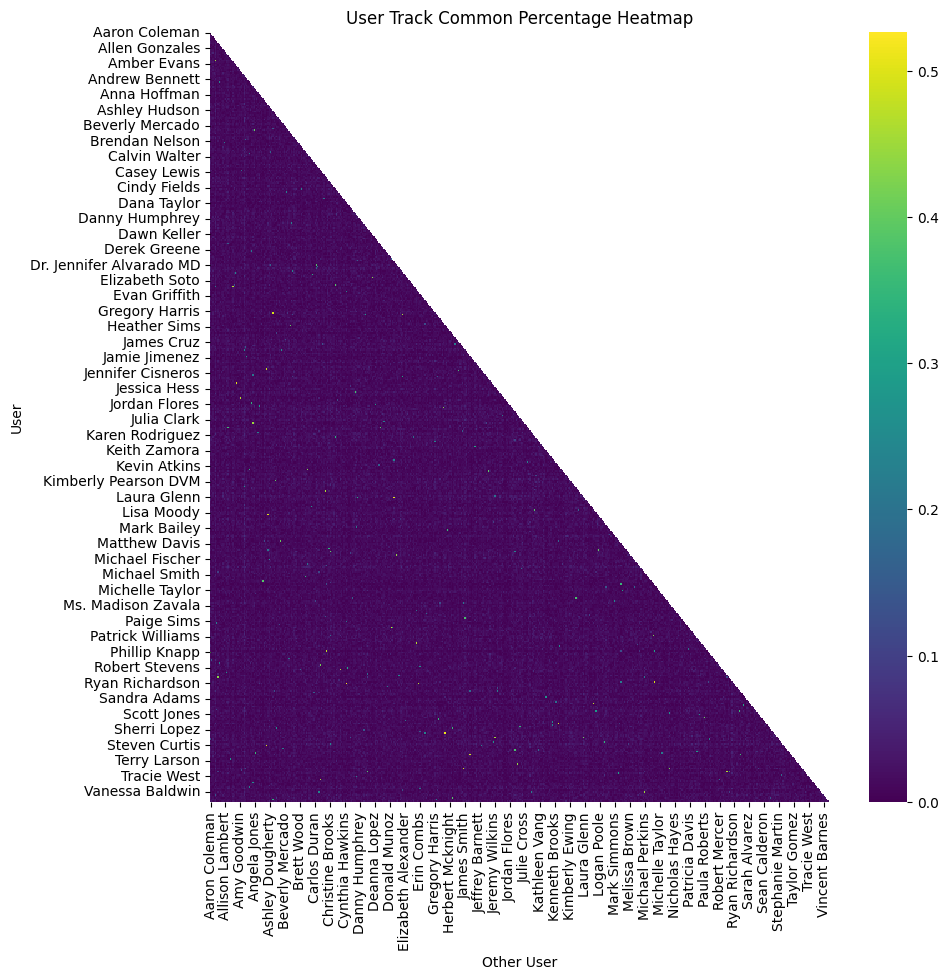

In [6]:
plot_user_similarities_matrix(df_track_common, figsize=(10, 10))

In [7]:
df.data.to_csv(os.path.join("data", "artificial_data.csv"))

In [8]:
M = MatrixDataset(df.data, user_col="username", item_col="id", value_col="affinity")
M.R.shape

torch.Size([497, 53478])